# CNN Pneumonia Detection


---
## Install & Import

In [1]:
!pip install kagglehub[pandas-datasets] --quiet

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models

import kagglehub
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("TensorFlow version:", tf.__version__)
print("All libraries imported!")

TensorFlow version: 2.20.0
All libraries imported!


---
## Download Dataset

In [3]:
path = kagglehub.dataset_download("mahabubalam31/chest-x-ray-dataset-for-pneumoniabalanced")

print("Dataset saved at:", path)
print("Folders inside dataset:", os.listdir(os.path.join(path, "dataset")))

Using Colab cache for faster access to the 'chest-x-ray-dataset-for-pneumoniabalanced' dataset.
Dataset saved at: /kaggle/input/chest-x-ray-dataset-for-pneumoniabalanced
Folders inside dataset: ['Data_Entry_2017.csv', 'VAL', 'TEST', 'TRAIN']


---
## Check Dataset
Before training, we checked two things:
1. Are there any **broken images**? (They crash training)
2. Are the classes **balanced**? (Equal Normal vs Pneumonia counts)

In [4]:
#Count images per class
def count_classes(folder_path):
    counts = {}
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            counts[class_name] = len(os.listdir(class_folder))
    return counts

print("Train:",      count_classes(os.path.join(path, "dataset", "TRAIN")))
print("Validation:", count_classes(os.path.join(path, "dataset", "VAL")))
print("Test:",       count_classes(os.path.join(path, "dataset", "TEST")))

Train: {'PNEUMONIA': 4563, 'NORMAL': 4563}
Validation: {'PNEUMONIA': 543, 'NORMAL': 566}
Test: {'PNEUMONIA': 570, 'NORMAL': 571}


In [5]:
#Find corrupt images
def find_corrupt(folder_path):
    bad = []
    for root, _, files in os.walk(folder_path):
        for fname in files:
            fpath = os.path.join(root, fname)
            try:
                Image.open(fpath).verify()
            except:
                bad.append(fpath)
    return bad

corrupt = find_corrupt(os.path.join(path, "dataset", "TRAIN"))
print("Corrupt images found:", len(corrupt))
if corrupt:
    print(corrupt)

Corrupt images found: 0


---
## Visualize Sample Images

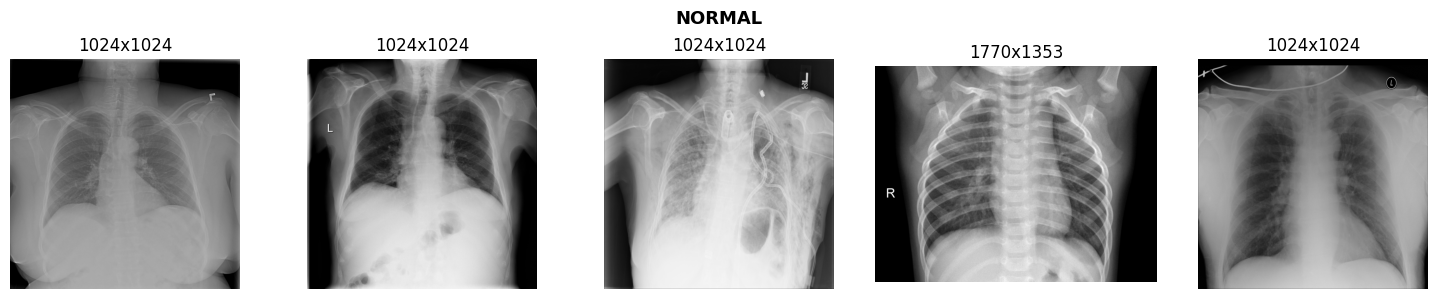

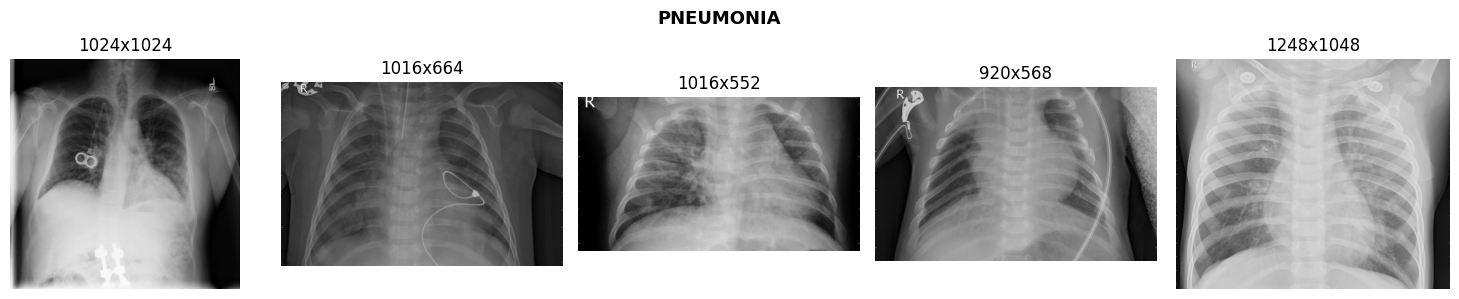

In [6]:
train_path = os.path.join(path, "dataset", "TRAIN")

for cls in ["NORMAL", "PNEUMONIA"]:
    cls_path  = os.path.join(train_path, cls)
    img_names = random.sample(os.listdir(cls_path), 5)

    plt.figure(figsize=(15, 3))
    plt.suptitle(cls, fontsize=13, fontweight='bold')

    for i, name in enumerate(img_names):
        img = Image.open(os.path.join(cls_path, name))
        plt.subplot(1, 5, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{img.size[0]}x{img.size[1]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# understand that:
# NORMAL   → clear, dark lungs
# PNEUMONIA → white patches in the lung area

---
## Preprocessing

We cleaning and standardizing using 3 steps before feeding images to the CNN.

3 steps:

| Step | What it does | Why |
|----------|-------------|-----|
| Resize | All images → 224×224 px | CNN needs a fixed input size |
| CLAHE | Boost local contrast | X-rays are often foggy/low contrast |
| Normalize | Pixel values 0–255 → 0.0–1.0 | Smaller numbers → faster, stable training |

In [7]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    f'{path}/dataset/TRAIN',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    color_mode='grayscale',
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f'{path}/dataset/VAL',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f'{path}/dataset/TEST',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

class_names = train_ds.class_names
print("Label encoding:  0 =", class_names[0], " | 1 =", class_names[1])

Found 9126 files belonging to 2 classes.
Found 1109 files belonging to 2 classes.
Found 1141 files belonging to 2 classes.
Label encoding:  0 = NORMAL  | 1 = PNEUMONIA


In [8]:
#CLAHE — boost contrast ───────────────────────────────────────────────
#CLAHE = Contrast Limited Adaptive Histogram Equalization
#It makes foggy X-rays sharper then CNN can spot pneumonia patterns more easily.
#We use OpenCV's CLAHE and wrap it so TensorFlow can use it.

def apply_clahe(img_numpy):
    """Apply CLAHE contrast enhancement to a batch of images."""
    if img_numpy.max() <= 1.01:          # If already 0-1, scale up for OpenCV
        img_numpy = img_numpy * 255.0

    clahe = cv2.createCLAHE(clipLimit=1.2, tileGridSize=(8, 8))
    result = []

    for i in range(img_numpy.shape[0]):                     # Loop over each image in batch
        single = img_numpy[i, :, :, 0].astype(np.uint8)    # Remove channel dim for OpenCV
        enhanced = clahe.apply(single)                       # Apply CLAHE
        normalized = enhanced.astype(np.float32) / 255.0    # Normalize back to 0-1
        result.append(normalized)

    return np.array(result)[..., np.newaxis].astype(np.float32)  # Add channel dim back


def preprocess(image, label):
    """Bridge: run CLAHE inside TensorFlow's data pipeline."""
    image = tf.numpy_function(apply_clahe, [image], tf.float32)
    image.set_shape([None, 224, 224, 1])   # Must tell TF the output shape
    return image, label


# Apply CLAHE to all splits
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(preprocess,   num_parallel_calls=tf.data.AUTOTUNE)
test_ds  = test_ds.map(preprocess,  num_parallel_calls=tf.data.AUTOTUNE)

print("CLAHE applied to all datasets.")

CLAHE applied to all datasets.


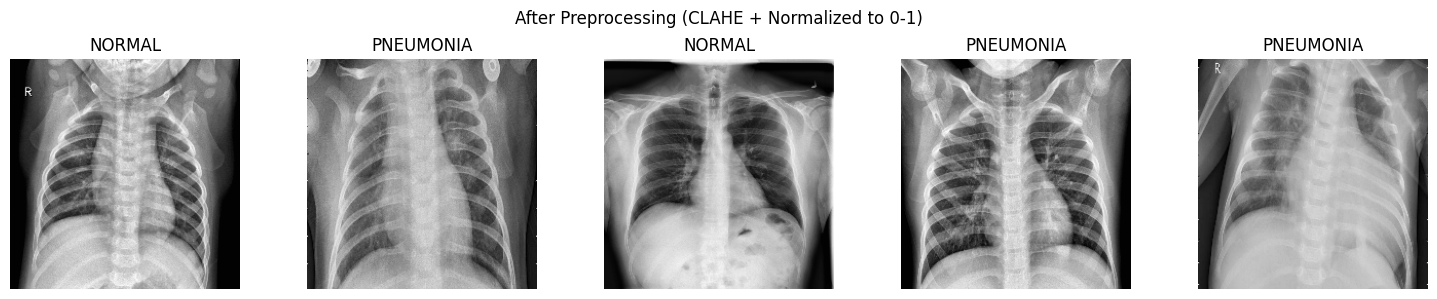

In [9]:
#Confirm preprocessing looks right
#After CLAHE the images should look sharper/higher contrast than the originals
for images, labels in train_ds.take(1):
    plt.figure(figsize=(15, 3))
    plt.suptitle("After Preprocessing (CLAHE + Normalized to 0-1)", fontsize=12)
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy().reshape(224, 224), cmap='gray', vmin=0, vmax=1)
        plt.title(class_names[int(labels[i])])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

---
## Data Augmentation

artificially creating more training variety by applying small random changes to each image.

This prevents the model from memorising the exact training images.

We only augment the **training** set — never val or test.

For medical X-rays we only use **safe** augmentations:
- ✅ Horizontal flip (left-right chest is symmetric)
- ✅ Small rotation (patient positioning)
- ✅ Small zoom (camera distance)
- ❌ Vertical flip (would make anatomy upside-down)
- ❌ Large rotation (unrealistic)

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.02, fill_mode='constant', fill_value=0.0),
    layers.RandomZoom(0.02, fill_mode='constant', fill_value=0.0)
])

print("Augmentation pipeline ready.")

Augmentation pipeline ready.


---
## Optimize the Pipeline for Speed

We use 3 tricks to make training fast:

| Trick | What it does |
|-------|--------------|
| `cache()` | Stores preprocessed images in RAM — epoch 2+ is 10× faster |
| Augment after cache | Augmentation stays random every epoch (applied after the fixed cache) |
| `prefetch()` | Loads next batch while GPU is still training on the current one |

In [11]:
# Store preprocessed images in RAM
train_ds = train_ds.cache()
val_ds   = val_ds.cache()
test_ds  = test_ds.cache()

# Apply augmentation AFTER cache so it randomizes every epoch
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Prefetch: prepare next batch while GPU works
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)

print("Pipeline optimized: Cache → Augment → Prefetch")

Pipeline optimized: Cache → Augment → Prefetch


---
## Build the CNN Model

Our CNN has 4 blocks. Each block does the same 3 things:

```
Conv2D        → finds patterns (edges, shapes, textures)
BatchNorm     → keeps values stable so training doesn't go crazy  ← NEW
MaxPooling    → shrinks the image in half (keeps important parts)
```

Then at the end:
```
Flatten → Dense(512) → Dropout(0.5) → Dense(1, sigmoid)
                                             ↓
                           output: 0.0 = Normal, 1.0 = Pneumonia
```

**Why Batch Normalization?**
After each Conv layer, values can get very large or very small.
BatchNorm rescales them back to a good range automatically.
Result: faster training, more stable, often better accuracy.

**Why Dropout?**
During training, randomly turn off 50% of neurons.
This forces the model to not rely on any single neuron → generalises better.

In [12]:
model = models.Sequential([

 # Input: grayscale image 224×224 pixels
 layers.Input(shape=(224, 224, 1)),

 # ── Block 1 ── Detect basic edges & shapes
 layers.Conv2D(32, (3, 3), padding='same'),
 layers.BatchNormalization(),     # Stabilize values after Conv
 layers.Activation('relu'),
 layers.MaxPooling2D((2, 2)),     # 224×224 → 112×112

 # ── Block 2 ── Detect textures & structures
 layers.Conv2D(64, (3, 3), padding='same'),
 layers.BatchNormalization(),
 layers.Activation('relu'),
 layers.MaxPooling2D((2, 2)),     # 112×112 → 56×56

 # ── Block 3 ── Detect complex lung patterns
 layers.Conv2D(128, (3, 3), padding='same'),
 layers.BatchNormalization(),
 layers.Activation('relu'),
 layers.MaxPooling2D((2, 2)),     # 56×56 → 28×28

 # ── Block 4 ── Refine features
 layers.Conv2D(128, (3, 3), padding='same'),
 layers.BatchNormalization(),
 layers.Activation('relu'),
 layers.MaxPooling2D((2, 2)),     # 28×28 → 14×14

 # ── Classifier Head ──
 layers.Flatten(),               # 14×14×256 → flat vector
 layers.Dense(256),
 layers.Activation('relu'),
 layers.Dropout(0.5),             # prevent overfitting

 layers.Dense(1, activation='sigmoid')  # Output: Normal (0) / Pneumonia (1)
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,664,705 (25.42 MB)

 Trainable params: 6,664,001 (25.42 MB)

 Non-trainable params: 704 (2.75 KB)

---
## Compile the Model

Compiling means telling the model **how to learn**:

| Setting | Choice | Why |
|---------|--------|-----|
| Optimizer | Adam (lr=0.0001) | Best general-purpose optimizer; low lr = stable |
| Loss | binary_crossentropy | Correct for 2-class (binary) problems |
| Metrics | accuracy + AUC | Accuracy is simple; AUC better for medical diagnosis |

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss= 'binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='prc', curve='PR')]
)

print("Model compiled and ready to train!")

Model compiled and ready to train!


---
## Set Up Training Callbacks

Callbacks are helpers that run automatically during training:

| Callback | What it does |
|----------|--------------|
| EarlyStopping | Stops training if no improvement for 5 epochs (saves time) |
| ModelCheckpoint | Saves the best model automatically |
| ReduceLROnPlateau | Slows down learning rate if stuck (helps fine-tune) |

Also: **class weights** — since missing a pneumonia case is more dangerous than a false alarm,
we penalize pneumonia mistakes 3× harder.

In [14]:
# Stop training early if val_loss doesn't improve for 5 epochs
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,  # Auto-load the best checkpoint when done
    verbose=1
)

# Save the best model to disk during training
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_pneumonia_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Reduce learning rate by half if no improvement for 3 epochs
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Penalize pneumonia errors 3× more than normal errors
class_weights = {0: 1.0, 1: 1.9}

print("Callbacks ready!")

Callbacks ready!


---
## Train the Model
This is where the model learns. Each **epoch** = one full pass over all training images.
Watch `val_loss` — it should go down. If it starts going up and train_loss keeps going down, the model is overfitting.

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,               # Max 50 epochs — EarlyStopping will stop before this
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

print("\nTraining complete!")

Epoch 1/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 134s 423ms/step - accuracy: 0.7618 - loss: 0.7434 - prc: 0.8290 - val_accuracy: 0.5302 - val_loss: 0.6387 - val_prc: 0.8372 - learning_rate: 1.0000e-04
Epoch 2/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.8132 - loss: 0.5251 - prc: 0.9198 - val_accuracy: 0.8043 - val_loss: 0.4040 - val_prc: 0.9397 - learning_rate: 1.0000e-04
Epoch 3/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 29s 100ms/step - accuracy: 0.8195 - loss: 0.5036 - prc: 0.9258 - val_accuracy: 0.8206 - val_loss: 0.3956 - val_prc: 0.9169 - learning_rate: 1.0000e-04
Epoch 4/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 29s 101ms/step - accuracy: 0.8235 - loss: 0.4924 - prc: 0.9308 - val_accuracy: 0.8512 - val_loss: 0.3496 - val_prc: 0.9335 - learning_rate: 1.0000e-04
Epoch 5/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.8286 - loss: 0.4860 - prc: 0.9305 - val_accuracy: 0.8323 - val_loss: 0.3726 - val_prc: 0.9291 - learning_rate: 1.0000e-04
Epoch 6/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 41s 

---
## Plot Training Curves

These graphs show how the model improved over time.

- **Good**: train and val curves stay close together and both improve
- **Overfitting**: train keeps improving but val gets worse
- **Underfitting**: both curves stay low / plateau early

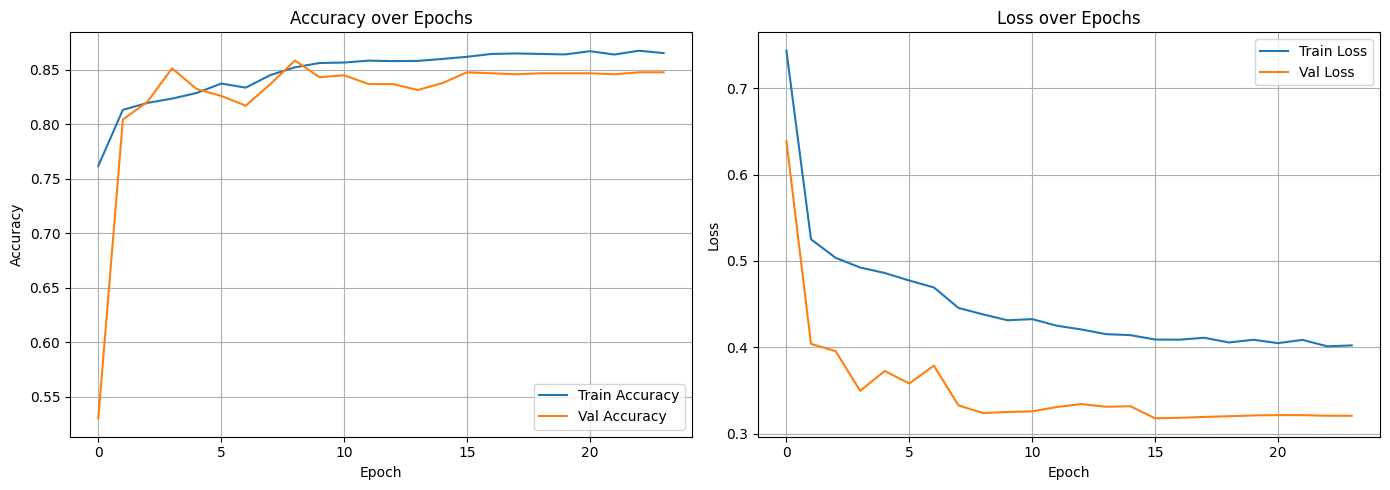

In [16]:
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs   = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc,     label='Train Accuracy')
plt.plot(epochs, val_acc, label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, loss,     label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

---
## Evaluation on Test Set

Now we test on images the model has **never seen before**.

Key metrics for medical diagnosis:
- **Sensitivity (Recall)** — how many pneumonia cases did we catch? (most important!)
- **Specificity** — how many healthy patients did we correctly clear?
- **AUC** — overall model quality (1.0 = perfect, 0.5 = random guessing)

In [17]:
# Quick evaluation with Keras
print("Test set results:")
test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=1)
print(f"  Loss:     {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  AUC:      {test_auc:.4f}")

Test set results:
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 350ms/step - accuracy: 0.8510 - loss: 0.3425 - prc: 0.9429
  Loss:     0.3425
  Accuracy: 0.8510
  AUC:      0.9429


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step


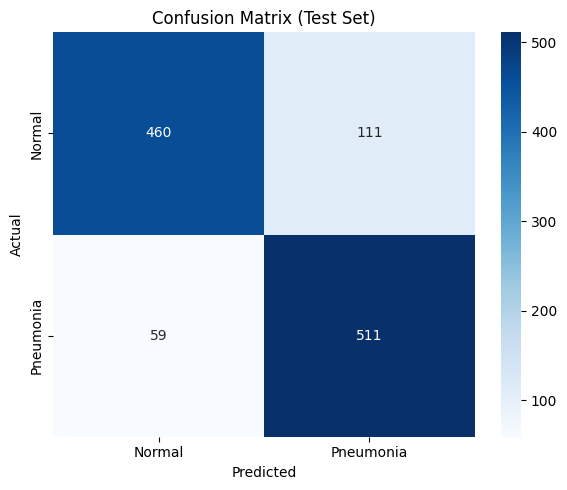


Results at threshold = 0.5:
  TP (Pneumonia caught):        511
  FN (Pneumonia MISSED ):     59
  TN (Normal correctly cleared): 460
  FP (False alarms):            111

  Sensitivity (catch rate): 0.896  ← most important
  Specificity:              0.806

              precision    recall  f1-score   support

      Normal       0.89      0.81      0.84       571
   Pneumonia       0.82      0.90      0.86       570

    accuracy                           0.85      1141
   macro avg       0.85      0.85      0.85      1141
weighted avg       0.85      0.85      0.85      1141



In [18]:
# Confusion matrix — shows exactly what the model got right/wrong
# Rows = actual label, Columns = predicted label

test_images = np.concatenate([x for x, y in test_ds], axis=0)
test_labels = np.concatenate([y for x, y in test_ds], axis=0)

# Get probability predictions (0.0 to 1.0)
probs = model.predict(test_images).flatten()

# Convert to class labels using threshold 0.5
preds = (probs >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(test_labels, preds)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

# Medical metrics
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"\nResults at threshold = 0.5:")
print(f"  TP (Pneumonia caught):        {tp}")
print(f"  FN (Pneumonia MISSED ):     {fn}")
print(f"  TN (Normal correctly cleared): {tn}")
print(f"  FP (False alarms):            {fp}")
print(f"")
print(f"  Sensitivity (catch rate): {sensitivity:.3f}  ← most important")
print(f"  Specificity:              {specificity:.3f}")
print()
print(classification_report(test_labels, preds, target_names=['Normal', 'Pneumonia']))

---
## Find the Best Threshold

The default threshold is 0.5, but we can choose a better one.

For medical diagnosis we usually **lower the threshold** (e.g. 0.3–0.4)
to catch more pneumonia cases, even if we get a few more false alarms.

The ROC curve helps us pick the right balance.

In [19]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

y_prob = model.predict(test_ds).flatten()
y_true = np.concatenate([y for x, y in test_ds], axis=0)

thresholds = np.linspace(0.3, 0.8, 101)

best = None
best_recall = 0

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    report = classification_report(
        y_true, y_pred, target_names=["Normal", "Pneumonia"], output_dict=True
    )

    acc = accuracy_score(y_true, y_pred)

    # Extract metrics
    n_prec = report["Normal"]["precision"]
    n_rec  = report["Normal"]["recall"]
    n_f1   = report["Normal"]["f1-score"]

    p_prec = report["Pneumonia"]["precision"]
    p_rec  = report["Pneumonia"]["recall"]
    p_f1   = report["Pneumonia"]["f1-score"]

    # ALL metrics ≥ 0.80
    if (n_prec >= 0.80 and n_rec >= 0.80 and n_f1 >= 0.80 and
        p_prec >= 0.80 and p_rec >= 0.80 and p_f1 >= 0.80 and
        acc >= 0.80):

        #maximize Pneumonia recall
        if p_rec > best_recall:
            best_recall = p_rec
            best = (t, acc, n_prec, n_rec, n_f1, p_prec, p_rec, p_f1)

# Result
if best:
    print("\n Best threshold (ALL metrics ≥ 0.80):")
    print(f"Threshold: {best[0]:.3f}")
    print(f"Accuracy: {best[1]:.3f}")

    print("\nNormal:")
    print(f"Precision: {best[2]:.3f}, Recall: {best[3]:.3f}, F1: {best[4]:.3f}")

    print("\nPneumonia:")
    print(f"Precision: {best[5]:.3f}, Recall: {best[6]:.3f}, F1: {best[7]:.3f}")
else:
    print("No threshold satisfies all ≥ 80% conditions.")

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step

 Best threshold (ALL metrics ≥ 0.80):
Threshold: 0.500
Accuracy: 0.851

Normal:
Precision: 0.886, Recall: 0.806, F1: 0.844

Pneumonia:
Precision: 0.822, Recall: 0.896, F1: 0.857


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


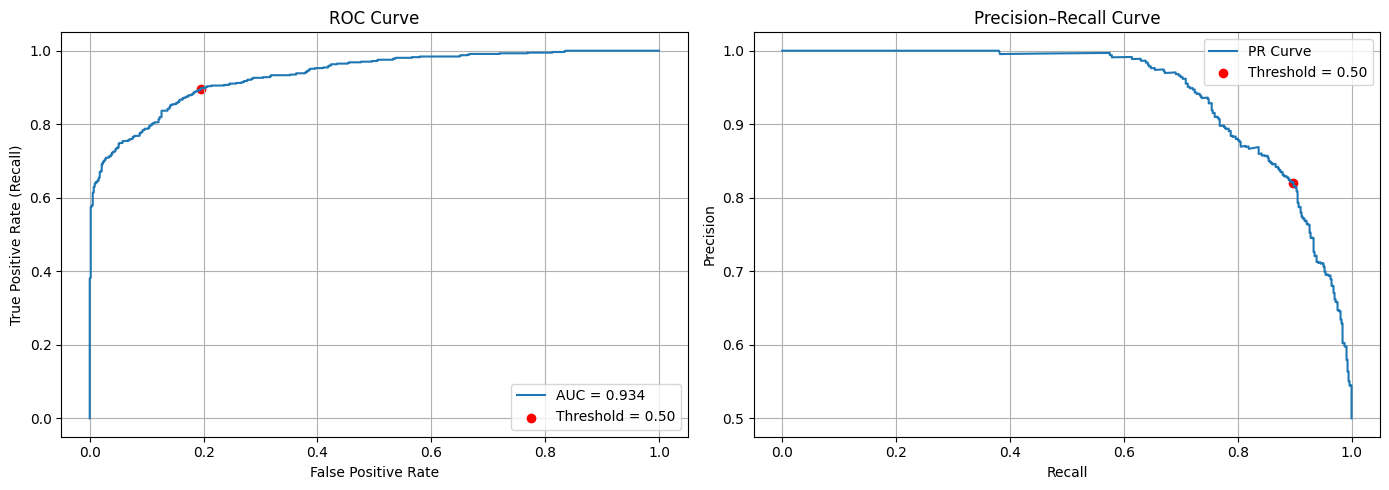

ROC-AUC: 0.934


In [20]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Get probabilities again (same as before)
y_prob = model.predict(test_ds).flatten()
y_true = np.concatenate([y for x, y in test_ds], axis=0)

#ROC Curve
fpr, tpr, roc_thresh = roc_curve(y_true, y_prob)
roc_auc = roc_auc_score(y_true, y_prob)

#PR Curve
precision, recall, pr_thresh = precision_recall_curve(y_true, y_prob)

#Find your best threshold location
if best:
    best_t = best[0]

    roc_idx = np.argmin(np.abs(roc_thresh - best_t))
    pr_idx  = np.argmin(np.abs(pr_thresh - best_t))
else:
    best_t = 0.5
    roc_idx = 0
    pr_idx = 0

# ── Plot ──────────────────────────────────
plt.figure(figsize=(14, 5))

#ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.scatter(fpr[roc_idx], tpr[roc_idx], color='red',
            label=f"Threshold = {best_t:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid()

#PR Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label="PR Curve")
plt.scatter(recall[pr_idx], precision[pr_idx], color='red',
            label=f"Threshold = {best_t:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.3f}")

---
## Save and Download the Model

In [21]:
from google.colab import files

model.save('pneumonia_model_final.keras')
print("Model saved as 'pneumonia_model_final.keras'")

#download model
files.download('pneumonia_model_final.keras')

Model saved as 'pneumonia_model_final.keras'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Predict on a New X-Ray Image

Now we use our trained model to predict on a single new image.

We must preprocess the new image exactly the same way as training images:
1. Convert to grayscale
2. Resize to 224×224
3. Apply CLAHE
4. Normalize to 0–1

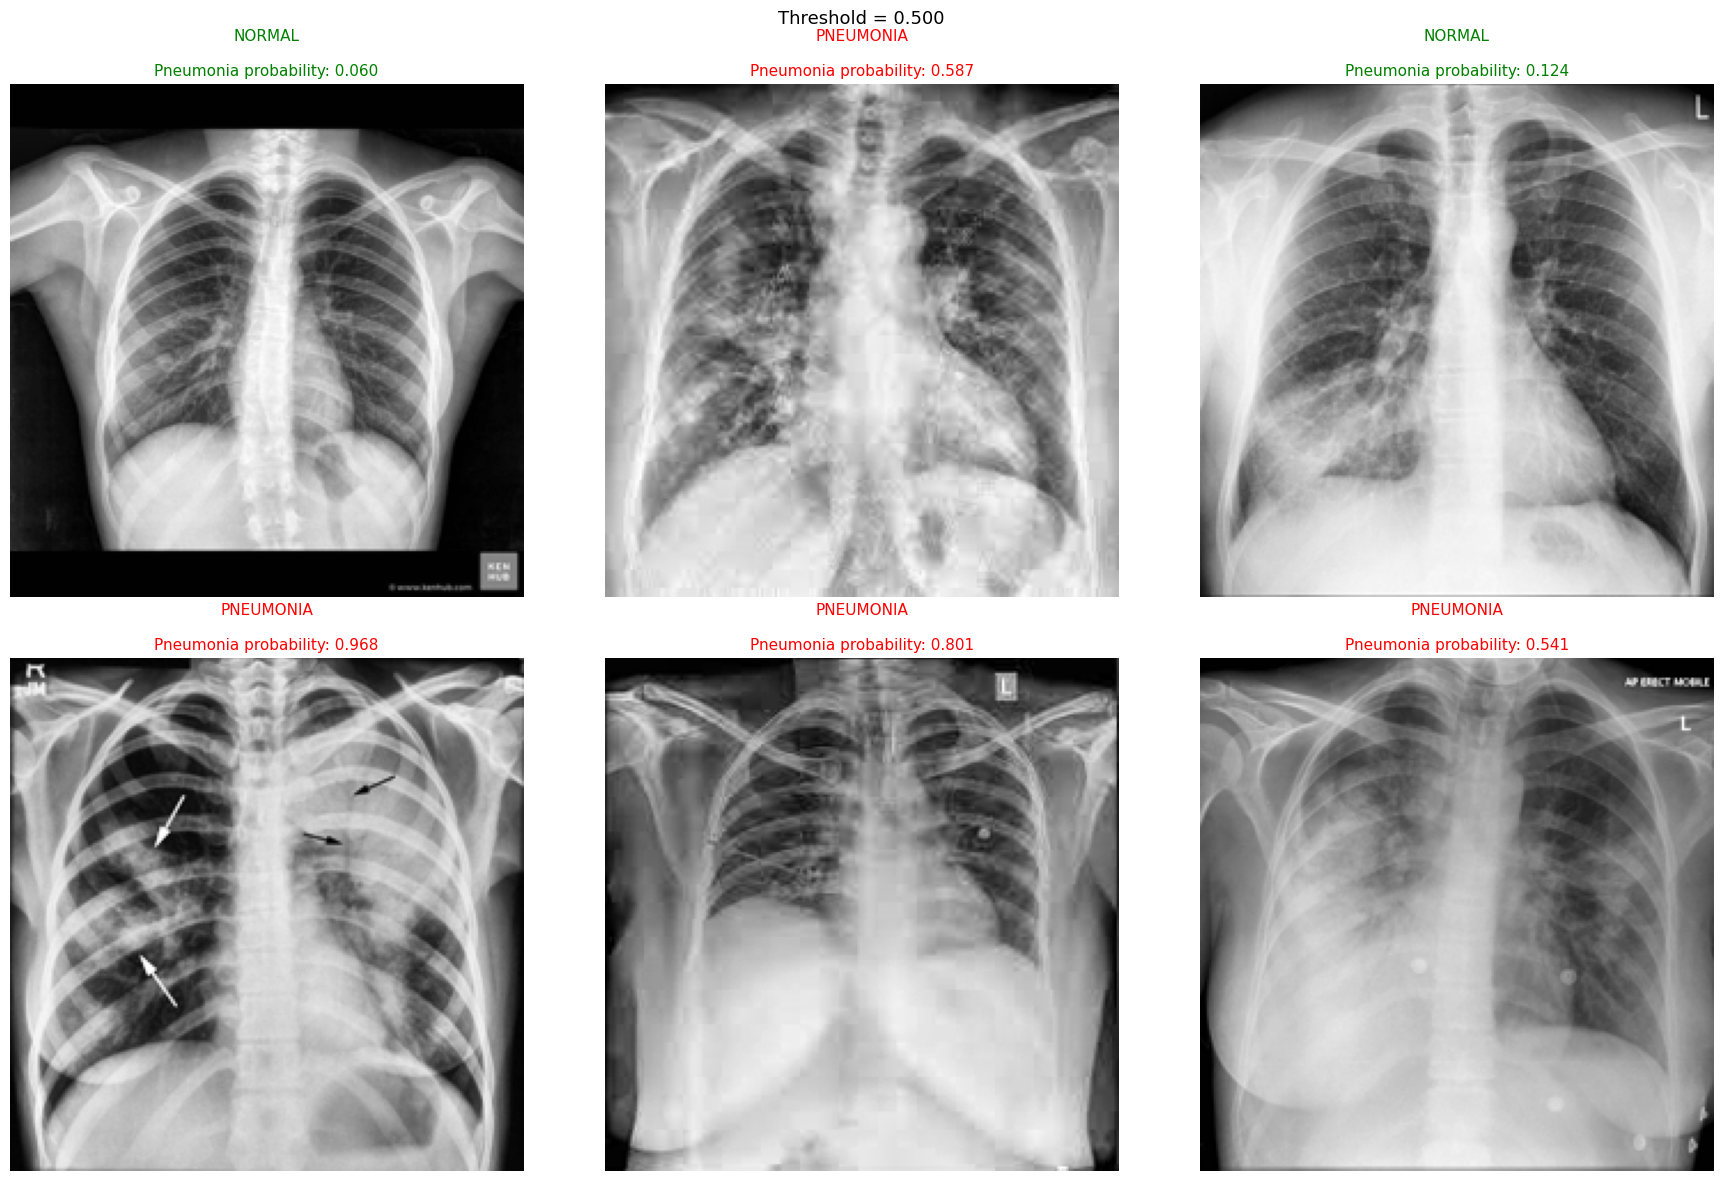

In [33]:
def preprocess_single_image(img_path):
    """Prepare one X-ray image for prediction (CORRECT PIPELINE)."""

    # 1. Load image and convert to grayscale
    img = Image.open(img_path).convert('L')

    # 2. Resize
    img = img.resize((224, 224))

    # 3. Convert to numpy (IMPORTANT: keep uint8 for CLAHE)
    img = np.array(img).astype(np.uint8)

    # 4. CLAHE (contrast enhancement)
    clahe = cv2.createCLAHE(clipLimit=1.2, tileGridSize=(8, 8))
    img = clahe.apply(img)

    # 5. Normalize (scale 0–1)
    img = img.astype(np.float32) / 255.0

    # 6. Add channel dimension (224,224,1)
    img = img[..., np.newaxis]

    # 7. Add batch dimension (1,224,224,1)
    img = np.expand_dims(img, axis=0)

    return img


# Put all test image filenames here
image_paths = [
    "normal img1.jpg",
    "normal img2.jpg",
    "normal img3.jpeg",
    "pneumonia img1.jpg",
    "pneumonia img2.jpg",
    "pneumonia img3.png"
]

best_thresh = best[0]

cols = 3
rows = (len(image_paths) + cols - 1) // cols
plt.figure(figsize=(6 * cols, 6 * rows))

for i, img_path in enumerate(image_paths):
    img   = preprocess_single_image(img_path)
    prob  = model.predict(img, verbose=0)[0][0]
    label = "PNEUMONIA" if prob >= best_thresh else "NORMAL"

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img[0, :, :, 0], cmap='gray')
    color = 'red' if label == 'PNEUMONIA' else 'green'
    plt.title(
        f"{label }\n\n"
        f"Pneumonia probability: {prob:.3f}",
        color=color, fontsize=11
    )
    plt.axis('off')

plt.suptitle(f"Threshold = {best_thresh:.3f}", fontsize=13)
plt.tight_layout()
plt.show()

---
## Summary

| Step | What we did |
|------|-------------|
| 1 | Installed and imported all libraries |
| 2 | Downloaded the dataset from Kaggle |
| 3 | Checked for corrupt images and class balance |
| 4 | Visualized raw X-ray samples |
| 5 | Preprocessed: resize → CLAHE contrast boost → normalize to 0-1 |
| 6 | Augmentation: flip, rotate, zoom (safe for medical images) |
| 7 | Optimized pipeline: cache → augment → prefetch |
| 8 | Built CNN with 4 blocks of Conv2D + **BatchNorm** + MaxPool |
| 9 | Compiled with Adam optimizer + binary crossentropy |
| 10 | Set up EarlyStopping + ModelCheckpoint + ReduceLROnPlateau |
| 11 | Trained the model |
| 12 | Plotted accuracy and loss curves |
| 13 | Evaluated: confusion matrix, sensitivity, specificity |
| 14 | Found best threshold using ROC + PR curves |
| 15 | Saved model to disk |
| 16 | Predicted on a new single X-ray image |